In [10]:
from typing_extensions import TypedDict
class State(TypedDict):
    graph_info:str

In [11]:
def start_play(state:State):
    print("start play Node has been Called")
    return{"graph_info":state['graph_info'] + "i am planninh to play "}

def cricket(state:State):
    print("My cricket Node Has Been Called")
    return{"graph_info":state['graph_info'] + "i am planninh to play Cricket"}

def Batminton(state:State):
    print("My batminton Node Has Been Called")
    return{"graph_info":state['graph_info'] + "i am planninh to play Batminton"}

In [12]:
from typing import Literal
import random
def random_play(state:State) -> Literal['cricket','Batminton']:
    graph_info = state['graph_info']
    
    if random.random() > 0.5 :
        return "cricket"
    else:
        return "Batminton"

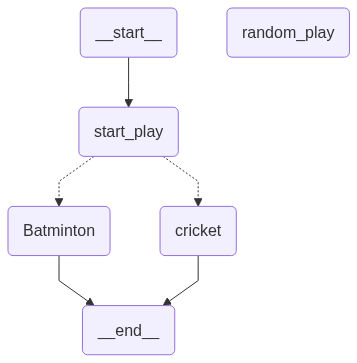

In [13]:
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

graph = StateGraph(State)

graph.add_node("start_play",start_play)
graph.add_node("cricket",cricket)
graph.add_node("Batminton",Batminton)
graph.add_node("random_play",random_play)

graph.add_edge(START,"start_play")
graph.add_conditional_edges("start_play",random_play)
graph.add_edge("cricket",END)
graph.add_edge("Batminton",END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [17]:
graph_builder.invoke({"graph_info":"Hey My Name Is Picard"})

start play Node has been Called
My cricket Node Has Been Called


{'graph_info': 'Hey My Name Is Picardi am planninh to play i am planninh to play Cricket'}